<a href="https://colab.research.google.com/github/yaelmagen/fraud-detection/blob/main/Nuvei_fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Multilayered Fraud Detection System

**Overview:**

I developed a robust, production-ready fraud detection engine designed to identify sophisticated payment anomalies within a user cohort dataset. The system transitions from raw data ingestion to a tiered decision-making framework, balancing statistical machine learning with deterministic business logic

**Methodology & Feature Engineering:**

- Behavioral Profiling: Engineered high-impact features including amount_to_avg_ratio (detecting spikes up to 204x) and Same-Amount Velocity to capture automated bot bursts.
- Geographic Risk: Developed cross-region "Impossible Travel" and "Suspicious Velocity" indicators to monitor account integrity across 134 countries.
- Data Integrity: Identified and isolated "Broken Records" (missing device/payment metadata), treating them as high-risk behavioral indicators.


**Hybrid Detection Engine:**

Recognizing that no single algorithm is a silver bullet, I implemented a Dual-Lens Ensemble:
- **Isolation Forest (Global Outliers):** Effectively captured high-magnitude anomalies, such as extreme transaction amounts and seniority-based risks.
- **Local Outlier Factor (Local Context):** Successfully identified 145 unique "silent" anomalies (e.g., high-value transactions in rare regions) that were overlooked by global modeling.
- **Deterministic Rules Layer:** Implemented "Hard Flags" for immediate blocking of high-confidence violations (Geographic Impossibility), ensuring 100% coverage for clear logical risks.

**Data Insights & Scalability**

Data consisted of transactions of users who joined the platform in June 2024 and contains their first 5 months of activity. Analysis revealed a natural Cohort Aging process. Given the temporal drift observed in the dataset, a rolling window retraining strategy could be implemented in production to ensure the model remains aligned twith recent use behavior and fraud patterns.


**Limitations & aspects to consider:**
  - cold start problem
  - dataset includes only the first five months of user activity following onboarding which limits the ability to capture long-term behavioral patterns and seasonal effects

I addressed the Cold Start problem using a three-tiered approach:

**Mathematical Imputation:** Assigned neutral values to history-based features (a 1.0 ratio and 'infinite' time-delta) to prevent false positives during a user's first transaction.

**Contextual Encoding:** Provided the model with seniority and is_new_user flags, allowing it to differentiate between a legitimate lack of history and a suspicious deviation in behavior.

**Non-Historical Rules:** Leveraged deterministic indicators like Geographic Impossibility and Metadata Integrity (Broken Records), which provide immediate protection even when user profiling data is unavailable.

**Conclusion:**

The final system categorizes transactions into a tiered risk structure (Critical, High, Medium, Low), allowing for automated blocking of blatant fraud while optimizing manual review resources. This approach maximizes security coverage without compromising the user experience for legitimate global traffic.

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [13]:
file_name = 'DS_Test_Dataset.xlsx'

In [15]:
file_path = "."

In [16]:
raw_data = pd.read_excel(os.path.join(file_path, file_name))

In [17]:
raw_data.head()

,payment_id,user_id,merchant_id,payment_timestamp,first_approved_payment_timestamp,total_amount_usd,payment_instrument,currency,time_to_complete_payment,num_approved_payments_per_user,total_approved_amount_usd_per_user,country,state,device_type
0,66675334,11008761,210,2024-05-31 23:56:04.223,2024-05-31 23:56:04.223,109.86,credit_card,CAD,7.045880,1,109.86,CA,NaN,pc
1,66675371,11008762,117,2024-06-01 00:00:02.000,2024-06-01 00:00:02.149,108.71,credit_card,USD,3.236956,1,108.71,US,DC,mobile
2,66675434,11008768,248,2024-06-01 00:07:45.586,2024-06-01 00:07:45.586,150.00,credit_card,USD,3.431595,1,150.00,US,MO,mobile
3,66675492,11008775,288,2024-06-01 00:12:08.248,2024-06-01 00:12:08.248,30.00,credit_card,USD,1.600267,1,30.00,US,TX,mobile
4,66675558,11008784,160,2024-06-01 00:18:10.409,2024-06-01 00:18:10.409,41.42,credit_card,EUR,2.335492,1,41.42,FR,NaN,mobile


In [18]:
print("first registration date:", raw_data.first_approved_payment_timestamp.min())
print("last registration date:", raw_data.first_approved_payment_timestamp.max())

first registration date: 2024-05-31 23:56:04.223000
last registration date: 2024-06-30 23:54:03.575000


In [19]:
print("first approved payment date:", raw_data.payment_timestamp.min())
print("last approved payment date:", raw_data.payment_timestamp.max())

first approved payment date: 2024-05-31 23:56:04.223000
last approved payment date: 2024-10-28 11:47:18.139000


# EDA & Feature Engineering

Goals:

- General view
- Cleaning and handle missing values
- Features analysis
- Time aspect
- Adding indicators and new features

## General view and Sanity checks

In [20]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41321 entries, 0 to 41320
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   payment_id                          41321 non-null  int64         
 1   user_id                             41321 non-null  int64         
 2   merchant_id                         41321 non-null  int64         
 3   payment_timestamp                   41321 non-null  datetime64[ns]
 4   first_approved_payment_timestamp    41321 non-null  datetime64[ns]
 5   total_amount_usd                    41321 non-null  float64       
 6   payment_instrument                  41309 non-null  object        
 7   currency                            41321 non-null  object        
 8   time_to_complete_payment            41321 non-null  float64       
 9   num_approved_payments_per_user      41321 non-null  int64         
 10  total_approved_amount_

In [21]:
#convert object columns to category
obj_cols = raw_data.select_dtypes(include='object').columns
raw_data[obj_cols] = raw_data[obj_cols].astype("category")


In [22]:
categorical = [col for col in obj_cols]
categorical.append('merchant_id')

Check for duplications

In [23]:
#check that payment_id is globally unique
print("Duplicate payment_id:", raw_data['payment_id'].duplicated().sum())

Duplicate payment_id: 0


In [24]:
#check number of unique users
print("number of unique users", raw_data.user_id.nunique())

number of unique users 16208


In [25]:
#check if user_id maps to one country
raw_data.groupby('user_id')['country'].nunique().max() == 1

np.False_

In [26]:
sum(raw_data.groupby('user_id')['state'].nunique()!=1)

12620

In [27]:
sum(raw_data.groupby('user_id')['country'].nunique()!=1)

42

I identified 42 users active in multiple countries. While this can indicate legitimate travel or VPN usage, I flagged payments exhibiting 'Impossible Travel' patterns - where transactions occurred in different geographic locations within a timeframe that precludes physical travel. This is a strong indicator of potential Account Takeover (ATO) or credential sharing.

In [28]:
def get_region(country):
    central_west_europe = [
        'GB', 'DE', 'FR', 'IT', 'ES', 'NL', 'NO', 'PT', 'CH', 'AT', 'SE', 'DK', 'FI',
        'BE', 'IE', 'GR', 'LU', 'IS', 'MT', 'AD', 'MC', 'GL', 'AX', 'FO', 'GG', 'JE', 'LI',
        'PL', 'CZ', 'SK', 'HU', 'SI'
    ]

    east_europe_balkans = [
        'RO', 'UA', 'MD', 'EE', 'LT', 'LV', 'RS', 'MK', 'BA', 'AL', 'ME'
    ]

    me_caucasus = ['IL', 'CY', 'AM', 'GE', 'KZ', 'AZ', 'TR']

    if country in central_west_europe: return 'Central_West_Europe'
    if country in east_europe_balkans: return 'East_Europe_Balkans'
    if country in me_caucasus: return 'ME_Caucasus'

    if country in ['US', 'CA', 'MX', 'PR', 'AG', 'AW', 'BB', 'BM', 'BQ', 'BS', 'CW', 'DM', 'DO', 'GD', 'GP', 'GU', 'LC', 'MF', 'MQ', 'TC', 'VG', 'VI']: return 'North_America'
    if country in ['BR', 'CL', 'CO', 'PE', 'AR', 'UY', 'EC', 'GT', 'HN', 'CR', 'PY', 'SV', 'NI', 'GF', 'GY']: return 'South_Latam_America'
    if country in ['SG', 'JP', 'AE', 'IN', 'TW', 'MY', 'HK', 'BH', 'KW', 'QA', 'KH', 'ID', 'LA', 'KR', 'UZ', 'TH', 'NP', 'MN', 'TJ', 'LK', 'PK', 'OM', 'NC', 'PF', 'TO', 'TV']: return 'Asia_Oceania'
    if country in ['CI', 'MA', 'MU', 'BJ', 'GH', 'ET', 'BW', 'AO', 'RW', 'CG', 'LR', 'DZ', 'EG', 'MG', 'TN', 'TG', 'GQ', 'RE', 'SC']: return 'Africa'
    if country in ['AU', 'NZ', 'CK']: return 'Oceania'

    return 'Other'

raw_data['region'] = raw_data['country'].apply(get_region)


In [29]:
print(raw_data['region'].value_counts())


region
Central_West_Europe    21171
North_America          12858
East_Europe_Balkans     2100
Asia_Oceania            2085
Oceania                 1121
South_Latam_America      728
ME_Caucasus              714
Africa                   544
Name: count, dtype: int64


In [30]:
df_sorted = raw_data.sort_values(['user_id', 'payment_timestamp'])

df_sorted['prev_state'] = df_sorted.groupby('user_id')['state'].shift(1)
df_sorted['prev_country'] = df_sorted.groupby('user_id')['country'].shift(1)
df_sorted['prev_region'] = df_sorted.groupby('user_id')['region'].shift(1)
df_sorted['time_diff_hours'] = df_sorted.groupby('user_id')['payment_timestamp'].diff().dt.total_seconds() / 3600

#  Impossible Travel
cond_impossible = (df_sorted['region'] != df_sorted['prev_region']) & \
                  (df_sorted['prev_region'].notna()) & \
                  (df_sorted['time_diff_hours'] < 10)

#  Suspicious Velocity
cond_velocity = (
    ((df_sorted['region'] == df_sorted['prev_region']) & (df_sorted['prev_region'].notna())) &
    (
        ((df_sorted['country'] != df_sorted['prev_country']) & (df_sorted['prev_country'].notna())) |
        ((df_sorted['country'] == 'US') & (df_sorted['state'] != df_sorted['prev_state']) & (df_sorted['prev_state'].notna()))
    ) &
    (df_sorted['time_diff_hours'] < 3)
)

df_sorted['is_impossible_travel'] = cond_impossible.astype(int)
df_sorted['is_suspicious_velocity'] = cond_velocity.astype(int)

raw_data['is_impossible_travel'] = df_sorted['is_impossible_travel']
raw_data['is_suspicious_velocity'] = df_sorted['is_suspicious_velocity']

print(f"Impossible Travel detected: {raw_data['is_impossible_travel'].sum()}")
print(f"Suspicious Velocity detected: {raw_data['is_suspicious_velocity'].sum()}")

Impossible Travel detected: 8
Suspicious Velocity detected: 16


In [31]:
# Examine a single case
raw_data[raw_data.user_id==11023298]

,payment_id,user_id,merchant_id,payment_timestamp,first_approved_payment_timestamp,total_amount_usd,payment_instrument,currency,time_to_complete_payment,num_approved_payments_per_user,total_approved_amount_usd_per_user,country,state,device_type,region,is_impossible_travel,is_suspicious_velocity
4093,66782472,11023298,160,2024-06-06 03:41:38.151,2024-06-06 03:41:38.151,101.64,credit_card,AUD,6.626513,1,101.64,KH,NaN,mobile,Asia_Oceania,0,0
4129,66783700,11023298,160,2024-06-06 05:38:18.815,2024-06-06 03:41:38.151,101.67,credit_card,AUD,2.978205,2,203.31,KH,NaN,mobile,Asia_Oceania,0,0
4136,66784015,11023298,160,2024-06-06 06:08:28.860,2024-06-06 03:41:38.151,203.68,credit_card,AUD,3.103252,3,406.99,KH,NaN,mobile,Asia_Oceania,0,0
12912,66996655,11023298,160,2024-06-14 22:06:50.789,2024-06-06 03:41:38.151,66.06,credit_card,AUD,2.996734,4,473.05,KH,NaN,mobile,Asia_Oceania,0,0
12997,66998872,11023298,160,2024-06-15 00:45:45.447,2024-06-06 03:41:38.151,56.90,credit_card,AUD,4.146685,5,529.95,KH,NaN,mobile,Asia_Oceania,0,0
13020,67000009,11023298,160,2024-06-15 02:13:31.567,2024-06-06 03:41:38.151,101.74,credit_card,AUD,4.553214,6,631.69,KH,NaN,mobile,Asia_Oceania,0,0
13030,67000431,11023298,160,2024-06-15 02:49:58.969,2024-06-06 03:41:38.151,81.36,credit_card,AUD,3.928226,7,713.05,KH,NaN,mobile,Asia_Oceania,0,0
22837,67212832,11023298,160,2024-06-25 04:22:04.744,2024-06-06 03:41:38.151,42.00,credit_card,USD,9.276264,8,755.05,KH,NaN,mobile,Asia_Oceania,0,0
22842,67213087,11023298,160,2024-06-25 04:45:46.770,2024-06-06 03:41:38.151,101.74,credit_card,AUD,4.321008,9,856.79,KH,NaN,mobile,Asia_Oceania,0,0
22892,67214640,11023298,160,2024-06-25 06:58:43.755,2024-06-06 03:41:38.151,152.76,credit_card,AUD,6.896540,10,1009.55,KH,NaN,mobile,Asia_Oceania,0,0


In [32]:
raw_data[raw_data['is_impossible_travel']==1]

,payment_id,user_id,merchant_id,payment_timestamp,first_approved_payment_timestamp,total_amount_usd,payment_instrument,currency,time_to_complete_payment,num_approved_payments_per_user,total_approved_amount_usd_per_user,country,state,device_type,region,is_impossible_travel,is_suspicious_velocity
12012,66977469,11032816,238,2024-06-14 06:27:34.510,2024-06-14 06:11:11.547,254.73,credit_card,GBP,6.345379,2,4163.45,GB,NaN,mobile,Central_West_Europe,1,0
14071,67027129,11049238,406,2024-06-16 12:35:29.675,2024-06-14 17:54:40.126,2215.41,credit_card,GBP,4.419989,5,3490.37,GB,NaN,mobile,Central_West_Europe,1,0
20424,67161376,11069920,288,2024-06-22 14:56:08.904,2024-06-22 09:36:49.366,30.00,credit_card,USD,7.650579,4,203.53,DE,NaN,mobile,Central_West_Europe,1,0
23910,67231824,11032816,238,2024-06-25 22:34:15.861,2024-06-14 06:11:11.547,1116.47,credit_card,GBP,3.754343,5,12411.49,GB,NaN,mobile,Central_West_Europe,1,0
29620,67335127,11090498,602,2024-07-01 07:15:27.768,2024-06-29 21:55:32.274,178.80,credit_card,BRL,6.195133,4,611.49,BR,NaN,mobile,South_Latam_America,1,0
33575,67623076,11023298,160,2024-07-16 02:04:31.196,2024-06-06 03:41:38.151,67.48,credit_card,AUD,1.617701,15,1387.89,AU,NaN,mobile,Oceania,1,0
33576,67623257,11023298,160,2024-07-16 02:24:08.785,2024-06-06 03:41:38.151,33.74,credit_card,AUD,4.580430,16,1421.63,KH,NaN,mobile,Asia_Oceania,1,0
33820,67658273,11032816,238,2024-07-17 19:12:17.852,2024-06-14 06:11:11.547,134.52,credit_card,JPY,3.143180,10,16764.39,JP,NaN,mobile,Asia_Oceania,1,0


The analysis assumes the 'country' field represents the user's transaction origin (based on IP/GPS), allowing the detection of impossible travel patterns regardless of the merchant's physical location

In [33]:
#check if user_id maps to one first payment date
raw_data.groupby('user_id')['first_approved_payment_timestamp'].nunique().max() == 1

np.True_

In [34]:
#check for suspicous transactions
raw_data.loc[raw_data.total_amount_usd<=1].shape[0] == 0

True

In [35]:
user_tf = raw_data.groupby('user_id').agg(
    first_payment=('payment_timestamp', 'min'),
    last_payment=('payment_timestamp', 'max')
)
user_tf['activity_days'] = (user_tf['last_payment'] - user_tf['first_payment']).dt.days
user_tf['activity_days'].describe()

count    16208.000000
mean         7.916831
std         22.051259
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        121.000000
Name: activity_days, dtype: float64

Insights:
- More than 50% of users are one time users

In [36]:
# Check cardinality
raw_data[categorical].nunique()

payment_instrument      3
currency               59
country               134
state                  53
device_type             5
merchant_id            91
dtype: int64

In [37]:
raw_data[['payment_instrument','device_type']].value_counts()

payment_instrument  device_type
credit_card         mobile         34381
                    pc              6095
google_pay          mobile           385
credit_card         no_data          201
                    tablet           115
                    other             67
google_pay          pc                50
bank_transfer       mobile            14
google_pay          no_data            1
Name: count, dtype: int64

Check for missing values

In [38]:
missing = raw_data.isnull().mean().sort_values(ascending=False)
missing[missing > 0]

state                 0.700443
device_type           0.000290
payment_instrument    0.000290
dtype: float64

Insights:
- State is relevant only for US and therefore not present elsewhere
- very low percentage of missing values for device type and payment method (0.03%). since it is exactly the same percentage it might be the same rows so maybe the fact that it is missing is meaningfull




In [39]:
missing_data = raw_data[raw_data['device_type'].isna() | raw_data['payment_instrument'].isna()]

both_missing = missing_data[missing_data['device_type'].isna() & missing_data['payment_instrument'].isna()]

print(f"rows missing device_type : {raw_data['device_type'].isna().sum()}")
print(f"rows missing payment_method : {raw_data['payment_instrument'].isna().sum()}")
print(f"both missing: {len(both_missing)}")

if len(both_missing) == raw_data['device_type'].isna().sum():
    print("same rows.")
else:
    print("not same rows")

rows missing device_type : 12
rows missing payment_method : 12
both missing: 12
same rows.


In [40]:
raw_data[raw_data['device_type'].isna()]

,payment_id,user_id,merchant_id,payment_timestamp,first_approved_payment_timestamp,total_amount_usd,payment_instrument,currency,time_to_complete_payment,num_approved_payments_per_user,total_approved_amount_usd_per_user,country,state,device_type,region,is_impossible_travel,is_suspicious_velocity
999,66709990,11013255,160,2024-06-02 20:35:18.030,2024-06-02 20:35:18.030,150.00,NaN,USD,5.201039,1,150.00,US,TX,NaN,North_America,0,0
1042,66711676,11013467,579,2024-06-02 22:41:53.304,2024-06-02 22:41:53.304,60.58,NaN,EUR,5.981655,1,60.58,MT,NaN,NaN,Central_West_Europe,0,0
6416,66842696,11017624,579,2024-06-08 13:51:01.700,2024-06-08 13:51:01.700,95.25,NaN,GBP,4.181310,1,95.25,GB,NaN,NaN,Central_West_Europe,0,0
7577,66880677,11034252,579,2024-06-10 08:01:46.023,2024-06-10 08:01:46.023,128.70,NaN,DKK,7.504261,1,128.70,DK,NaN,NaN,Central_West_Europe,0,0
10961,66954966,11044603,579,2024-06-13 09:38:12.021,2024-06-13 09:38:12.021,51.54,NaN,EUR,7.448137,1,51.54,UA,NaN,NaN,East_Europe_Balkans,0,0
11653,66968282,11046392,579,2024-06-13 19:42:14.045,2024-06-13 19:42:14.045,270.00,NaN,USD,31.058294,1,270.00,UZ,NaN,NaN,Asia_Oceania,0,0
12556,66988065,11048803,160,2024-06-14 15:38:01.682,2024-06-14 15:38:01.682,480.00,NaN,USD,2.259987,1,480.00,US,SC,NaN,North_America,0,0
14813,67044963,11055675,288,2024-06-17 12:06:29.151,2024-06-17 12:06:29.151,55.69,NaN,EUR,17.581732,1,55.69,IT,NaN,NaN,Central_West_Europe,0,0
17574,67097354,11062442,288,2024-06-19 17:58:25.289,2024-06-19 17:58:25.289,76.30,NaN,GBP,3.075067,1,76.30,GB,NaN,NaN,Central_West_Europe,0,0
28350,67309513,11089752,417,2024-06-29 15:42:21.246,2024-06-29 15:42:21.246,117.92,NaN,EUR,2.869514,1,117.92,DE,NaN,NaN,Central_West_Europe,0,0


Since its just 12 rows I can manually inspect them and look for common pattern:
- its not the same user
-  they are not concentrated in a certain currency/country/time frame.
- They are not related to a very high/very low payment amount
- most rows (10 out of 12) this is the first payment of the user
- i will compare the time of completing payment to the standard of first payments

In [41]:
first_payments = raw_data[raw_data['num_approved_payments_per_user'] == 1]

missing_rows_mask = first_payments['device_type'].isna()

print("time to complete first payment")
print("-" * 30)
print("missing:")
print(first_payments[missing_rows_mask]['time_to_complete_payment'].describe())

print("\nvalid")
print(first_payments[~missing_rows_mask]['time_to_complete_payment'].describe())


time to complete first payment
------------------------------
missing:
count    10.000000
mean      8.716100
std       8.999579
min       2.259987
25%       3.351628
50%       5.591347
75%       7.490230
max      31.058294
Name: time_to_complete_payment, dtype: float64

valid
count    16198.000000
mean        21.483258
std        142.759867
min          0.470766
25%          2.711820
50%          4.862927
75%          8.928233
max       4245.027875
Name: time_to_complete_payment, dtype: float64


In [42]:
p95_time = raw_data['time_to_complete_payment'].quantile(0.95)

slow_missing = first_payments[missing_rows_mask & (first_payments['time_to_complete_payment'] > p95_time)]
print(f"out of missing rows, {len(slow_missing)} in the top 5% of completion time.")


out of missing rows, 1 in the top 5% of completion time.


Check cumulative logic, assuming all payments in file are approved

In [43]:
# total approved amount should be >= current transaction
inconsistency = (raw_data['total_approved_amount_usd_per_user'] < raw_data['total_amount_usd']).sum()
print("Inconsistent total amounts:", inconsistency)

Inconsistent total amounts: 0


In [44]:
df_sorted = raw_data.sort_values(['user_id', 'payment_timestamp'])
df_sorted['actual_row_count'] = df_sorted.groupby('user_id').cumcount() + 1
mismatched_rows = df_sorted[
    df_sorted['actual_row_count'] != df_sorted['num_approved_payments_per_user']
]

print(f"found {len(mismatched_rows)} mismatched rows.")

found 0 mismatched rows.


Does first approved payment exist for all users?

In [45]:
raw_data['payment_timestamp'] = pd.to_datetime(raw_data['payment_timestamp']).dt.floor('s')
raw_data['first_approved_payment_timestamp'] = pd.to_datetime(raw_data['first_approved_payment_timestamp']).dt.floor('s')

In [46]:
actual_first_payment = raw_data.groupby('user_id')['payment_timestamp'].min().reset_index()
actual_first_payment.columns = ['user_id', 'min_timestamp_in_file']

expected_first_payment = raw_data.groupby('user_id')['first_approved_payment_timestamp'].first().reset_index()

check_df = pd.merge(actual_first_payment, expected_first_payment, on='user_id')

missing_first_pay = check_df[check_df['min_timestamp_in_file'] != check_df['first_approved_payment_timestamp']]

print(f"Number of users missing first payment: {len(missing_first_pay)}")


Number of users missing first payment: 7


In [47]:
invalid_user_ids = missing_first_pay['user_id'].unique()

review_df = raw_data[raw_data['user_id'].isin(invalid_user_ids)].sort_values(['user_id', 'payment_timestamp'])

**Insights:** the dataset is truncated, missing some rows (randomly??). the missing rows are not restricted to a certain time point or time frame

## Handle missing values

In [48]:
# Flag missing in device type and distinguish it from no-data that might be due to privacy settings
raw_data['device_type'] = raw_data['device_type'].cat.add_categories('Unknown')
raw_data['payment_instrument'] = raw_data['payment_instrument'].cat.add_categories('Unknown')

raw_data['device_type'] = raw_data['device_type'].fillna('Unknown')
raw_data['is_broken_record'] = (raw_data['device_type'] == 'Unknown').astype(int)

#Flag missing in payment instrument
raw_data['payment_instrument'] = raw_data['payment_instrument'].fillna('Unknown')

In [49]:
# make sure state is null only for non-US
len(raw_data[(raw_data.state.isna())&(raw_data.country=='US')])==0

True

In [50]:
#  Handle 'state' for non-US countries

raw_data['geo_location'] = np.where(
    raw_data['country'] == 'US',
    raw_data['country'].astype(str) + "_" + raw_data['state'].astype(str).fillna('Unknown'),
    raw_data['country']
)

raw_data['is_us_transaction'] = (raw_data['country'] == 'US').astype(int)

## Numerical Features

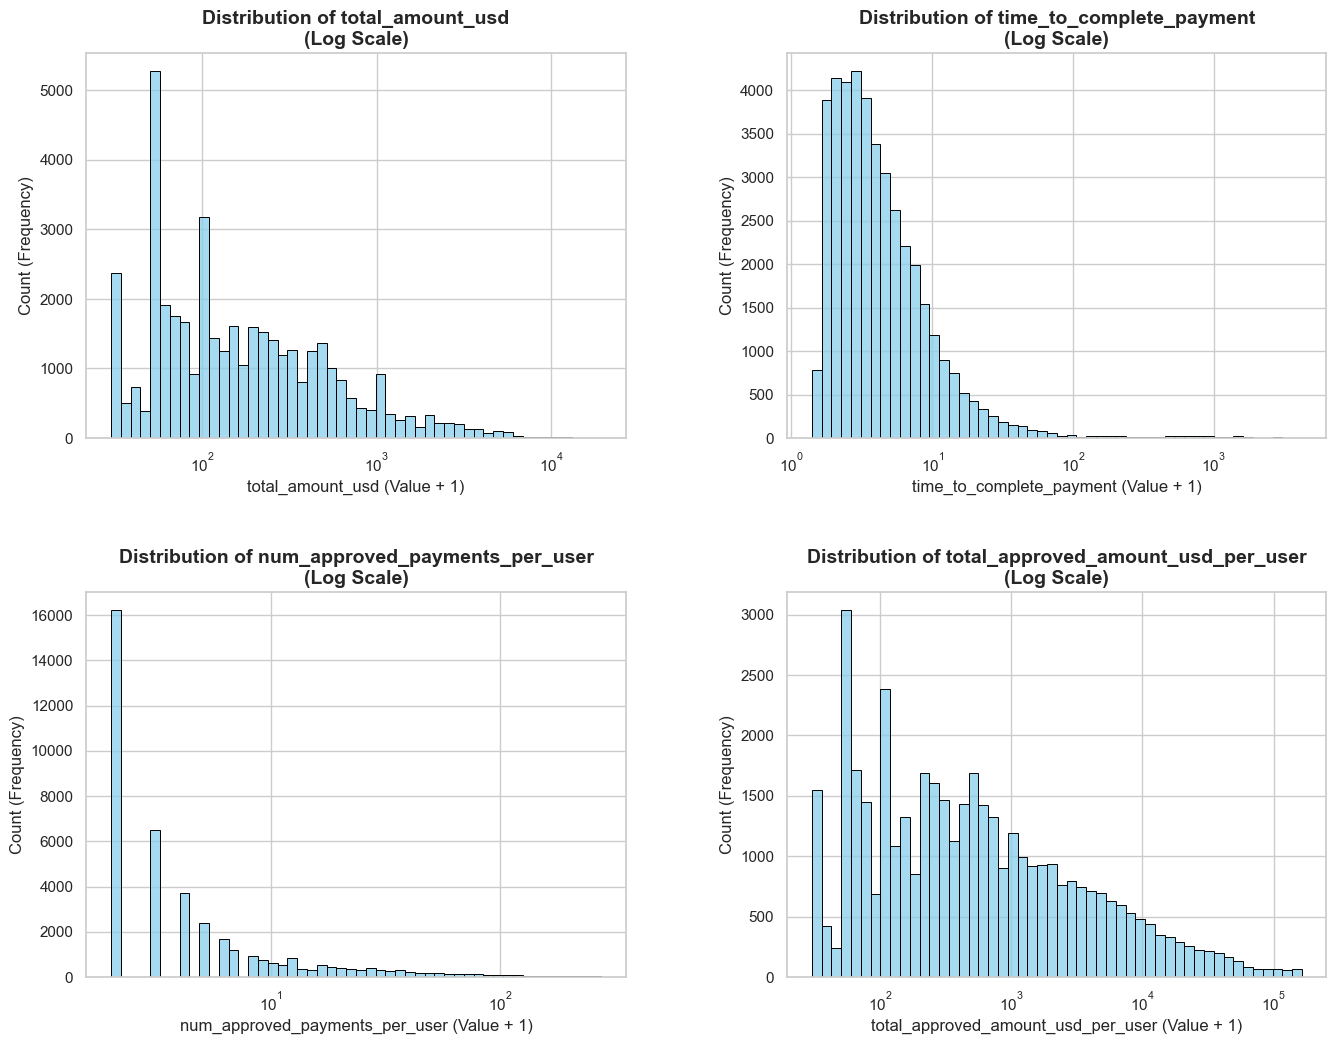

In [51]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

columns = [
    'total_amount_usd',
    'time_to_complete_payment',
    'num_approved_payments_per_user',
    'total_approved_amount_usd_per_user'
]

for i, col in enumerate(columns):
    ax = axes[i//2, i%2]

    sns.histplot(raw_data[col] + 1, bins=50, ax=ax, kde=False, log_scale=True, color='skyblue', edgecolor='black')

    ax.set_title(f'Distribution of {col}\n(Log Scale)', fontsize=14, fontweight='bold')
    ax.set_xlabel(f'{col} (Value + 1)', fontsize=12)
    ax.set_ylabel('Count (Frequency)', fontsize=12)

plt.show()

Features: total_amount_usd, time_to_complete_payment, num_approved_payments_per_user, total_approved_amount_usd_per_user

All four numerical features exhibit right-skewed distributions on a log scale. Transaction amounts cluster in the low-to-mid range with a long tail of high-value outliers. Payment completion time is concentrated around a few seconds. Most users have very few approved payments, and cumulative spending per user is heavily skewed toward low totals — consistent with a cohort dominated by low-frequency, low-value users.

## Feature Engineering

Adding new features:
- Seniority: Payments occurring within the user's first few seconds (Seniority ≈ 0) carry a higher risk level.
- Time Since Last Payment: An extremely short interval (seconds) may indicate a "replay attack" or a bot attempting to process transactions rapidly.
- Average Time: If a user typically pays once a month and suddenly processes many transactions in a single day, it triggers a red flag (Anomaly).


In [53]:
raw_data['payment_timestamp'] = pd.to_datetime(raw_data['payment_timestamp'])
raw_data = raw_data.sort_values(['user_id', 'payment_timestamp'])

raw_data['seniority'] = (raw_data['payment_timestamp'] - raw_data['first_approved_payment_timestamp']).dt.days

raw_data['time_since_last_payment'] = raw_data.groupby('user_id')['payment_timestamp'].diff().dt.total_seconds() / 3600

raw_data['avg_time_between_payments'] = raw_data.groupby('user_id')['time_since_last_payment'].transform(lambda x: x.expanding().mean()) # User Based - not to be used for modelling

In [54]:
raw_data['time_since_last_payment'] = raw_data['time_since_last_payment'].fillna(999999)

In [55]:
df_sorted = raw_data.sort_values(['user_id', 'payment_timestamp'])

df_sorted['prev_avg_amount'] = df_sorted.groupby('user_id')['total_amount_usd'].transform(lambda x: x.shift(1).expanding().mean())

df_sorted['amount_to_avg_ratio'] = (df_sorted['total_amount_usd'] / df_sorted['prev_avg_amount']).fillna(1)

In [56]:
raw_data['amount_to_avg_ratio'] = df_sorted['amount_to_avg_ratio']

I engineered the amount_to_avg_ratio feature to detect sudden shifts in purchasing behavior. The analysis revealed extreme outliers with ratios as high as 204x the user's historical average, involving transactions up to $12,000. These spikes are strong indicators of potential Account Takeover (ATO), where an established account is suddenly used for high-value fraudulent purchases that deviate significantly from previous activity


In [57]:
print(df_sorted['amount_to_avg_ratio'].describe())

count    41321.000000
mean         1.396797
std          2.418013
min          0.010256
25%          0.993566
50%          1.000000
75%          1.199944
max        204.198826
Name: amount_to_avg_ratio, dtype: float64


In [58]:
print(df_sorted[df_sorted['amount_to_avg_ratio'] > 1][['total_amount_usd', 'amount_to_avg_ratio']].sort_values('amount_to_avg_ratio', ascending=False).head(10))

       total_amount_usd  amount_to_avg_ratio
19067           8175.10           204.198826
17425           8910.16           138.614810
38862          12244.45           111.313182
25849          10000.00           100.000000
31234           6148.34            97.053512
9530            2763.80            72.312925
17702           5000.00            71.428571
5815            4000.00            66.666667
33305           5581.79            65.722242
19730           3110.73            61.562042


I identified a specific pattern where a user processed three identical transactions ($55.16) within a short timeframe, one of which was a 'broken record' with missing device data. To capture this, I engineered a Same-Amount Velocity feature. This ensures that rapid, identical-amount bursts—a common signature of automated bot attacks or credit card testing—are explicitly prioritized by the anomaly detection model.


In [59]:
df_sorted = raw_data.sort_values(['user_id', 'payment_timestamp'])

df_sorted['is_same_as_prev_amount'] = (
    (df_sorted['total_amount_usd'] == df_sorted.groupby('user_id')['total_amount_usd'].shift(1))
).astype(int)

raw_data['is_same_as_prev_amount'] = df_sorted['is_same_as_prev_amount']

In [60]:
temp_series = df_sorted.set_index('payment_timestamp')

rolling_count = (
    temp_series.groupby(['user_id', 'total_amount_usd'])['total_amount_usd']
    .rolling('24h', closed='left')
    .count()
)

df_sorted['same_amount_count_24h'] = rolling_count.values
df_sorted['same_amount_count_24h'] = df_sorted['same_amount_count_24h'].fillna(0)

raw_data['same_amount_count_24h'] = df_sorted['same_amount_count_24h']

In [61]:
raw_data['same_amount_count_24h'].describe() # value of 1 is suspicous and need to be reviewed, values above 1 are anomalies

count    41321.000000
mean         0.099901
std          0.559517
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         15.000000
Name: same_amount_count_24h, dtype: float64

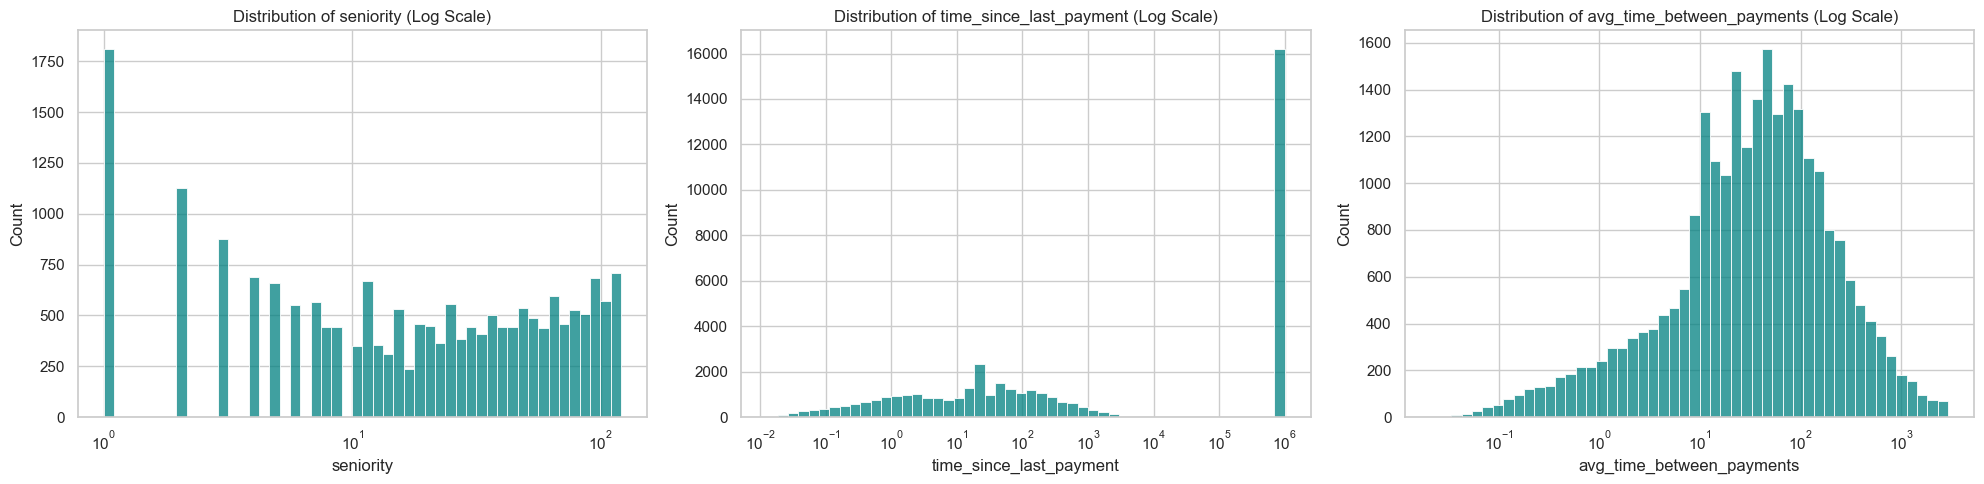

In [62]:
new_features = ['seniority', 'time_since_last_payment', 'avg_time_between_payments']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, col in enumerate(new_features):
    plot_data = raw_data[raw_data[col] > 0][col]

    sns.histplot(plot_data, bins=50, ax=axes[i], log_scale=True, color='teal')
    axes[i].set_title(f'Distribution of {col} (Log Scale)')

plt.tight_layout()
plt.show()


Features: seniority, time_since_last_payment, avg_time_between_payments

Seniority (days since first payment) shows a broad spread reflecting the 5-month observation window, with a peak at early tenure. Time since last payment and average time between payments are both heavily right-skewed on log scale, indicating most transactions follow shortly after a previous one, while a long tail represents dormant or infrequent users.

In [63]:
raw_data['is_new_user'] = (raw_data.num_approved_payments_per_user ==  1)

## Categorical Features Analysis

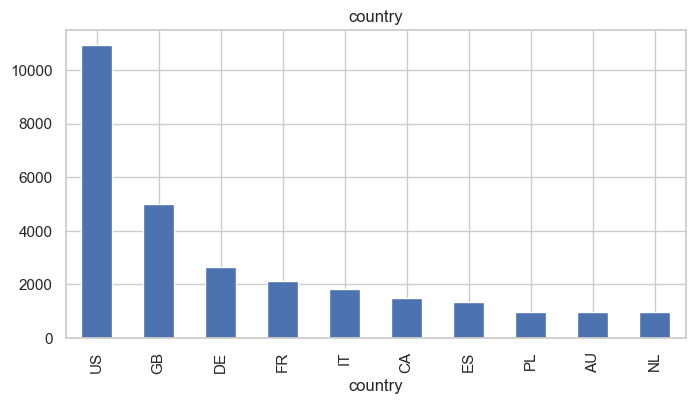

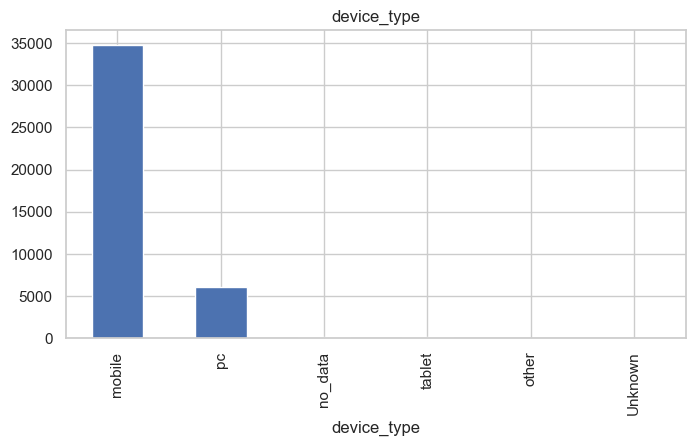

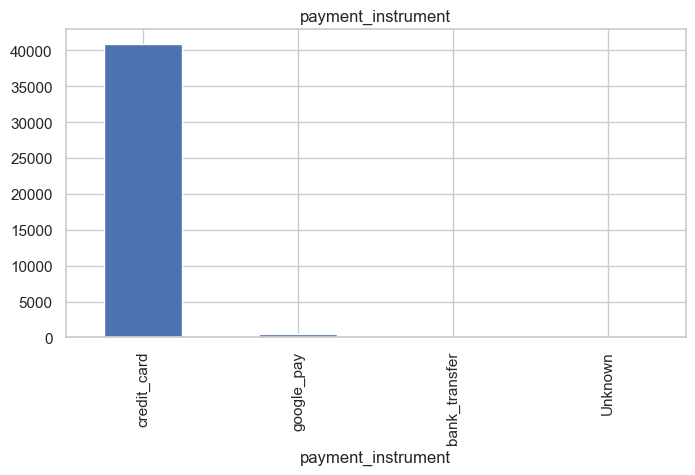

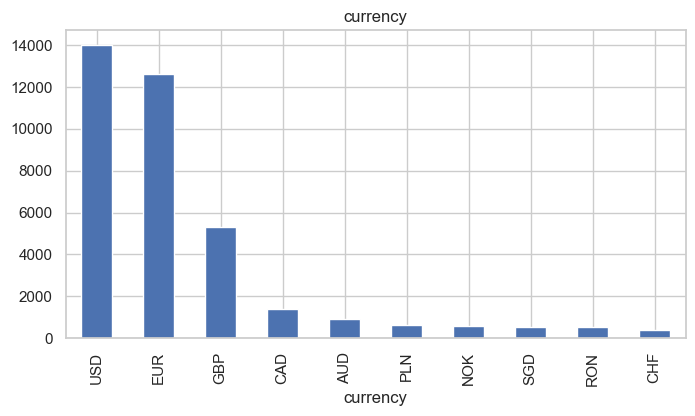

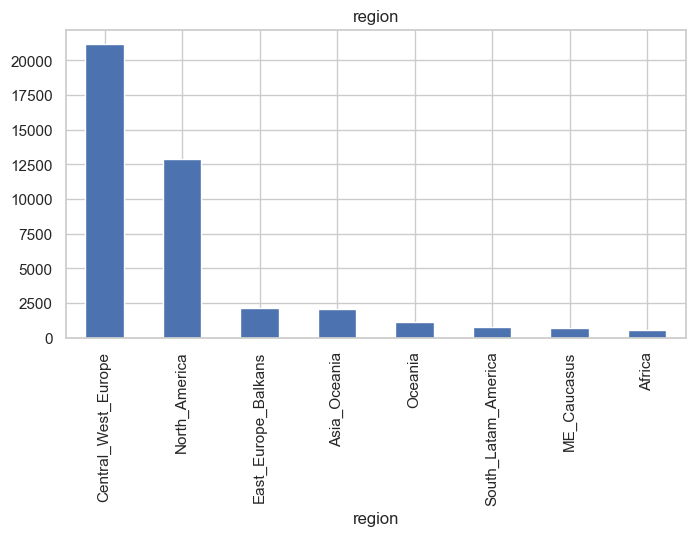

In [64]:
cat_cols = ['country', 'device_type', 'payment_instrument', 'currency', 'region']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    raw_data[col].value_counts().head(10).plot(kind='bar')
    plt.title(col)
    plt.show()

Features: country, device_type, payment_instrument, currency, region

- Country distribution is dominated by The US, followed by GB and DE.
- Device type is overwhelmingly "mobile" with "pc" as a distant second.
- Payment instrument is almost exclusively "credit_card".
- Currency distribution mirrors the geographic spread (USD, EUR, GBP lead).
- Region shows Central/West Europe and North America accounting for the vast majority of traffic

- Merchant - maybe some merchants have lower security
- check for high concentration of impossible travel transactions or broken records

In [66]:
merchant_risk = raw_data.groupby('merchant_id')['is_impossible_travel'].mean().sort_values(ascending=False)
print(merchant_risk.head(10))

merchant_id
238    0.003024
406    0.002188
602    0.000292
160    0.000259
288    0.000096
399    0.000000
470    0.000000
552    0.000000
535    0.000000
519    0.000000
Name: is_impossible_travel, dtype: float64


While is_impossible_travel occurs only across 5 merchants, I opted to include merchant_id via Frequency Encoding rather than creating a manual joint feature. This allows the model to naturally capture the interaction between specific merchants and geographic risks without over-fitting to current data

In [67]:
merchant_stats = raw_data.groupby('merchant_id')['total_amount_usd'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])

# Card Testing?
small_amount_merchants = merchant_stats[merchant_stats['median'] < 2].sort_values('count', ascending=False)

#high volume
whale_merchants = merchant_stats[merchant_stats['median'] > 1000].sort_values('count', ascending=False)

print("Card Testing suspected:")
print(small_amount_merchants.head())

Card Testing suspected:
Empty DataFrame
Columns: [mean, median, std, min, max, count]
Index: []


In [68]:
broken_rows = raw_data[raw_data['device_type']=='Unknown']

broken_merchants = broken_rows['merchant_id'].value_counts()

print("distribution of merchants in broken records:")
print(broken_merchants)

if len(broken_merchants) == 1:
    print(f"All records root to the same merchant {broken_merchants.index[0]}")
else:
    print("Records spread across merchants")

distribution of merchants in broken records:
merchant_id
579    5
288    3
160    2
237    1
417    1
Name: count, dtype: int64
Records spread across merchants


## Time Based Analysis

In [69]:
raw_data['hour'] = raw_data['payment_timestamp'].dt.hour
raw_data['day'] = raw_data['payment_timestamp'].dt.date
raw_data['weekday'] = raw_data['payment_timestamp'].dt.weekday

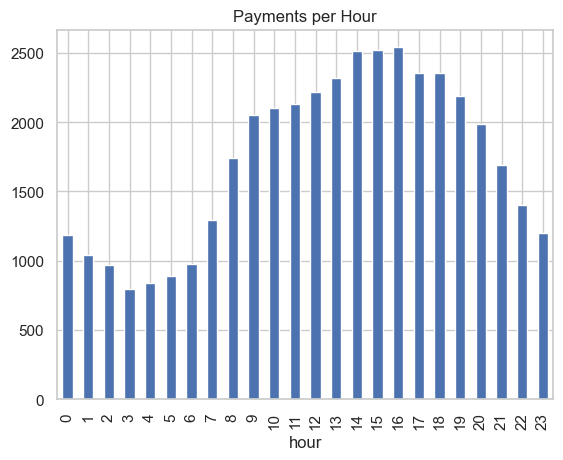

In [70]:
raw_data['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("Payments per Hour")
plt.show()

Transaction volume peaks in the afternoon hours (~12:00–18:00) and is lowest between 03:00–05:00.

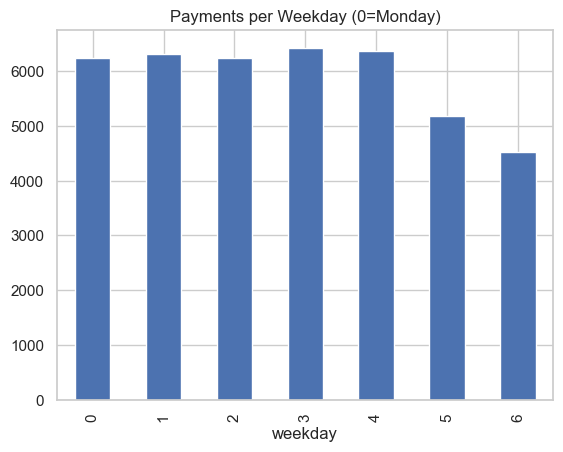

In [71]:
raw_data['weekday'].value_counts().sort_index().plot(kind='bar')
plt.title("Payments per Weekday (0=Monday)")
plt.show()

Weekdays (Mon–Fri) carry significantly higher transaction volume than weekends (Sat–Sun).

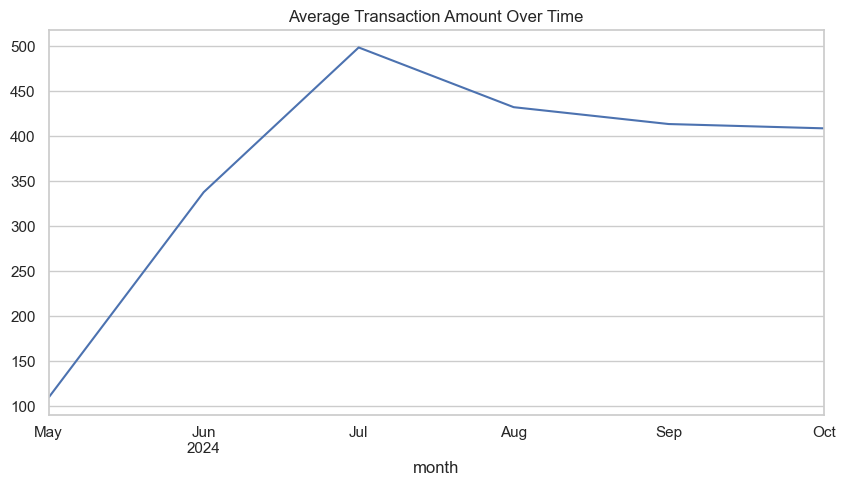

In [72]:
raw_data['month'] = raw_data['payment_timestamp'].dt.to_period('M')

monthly_amount = raw_data.groupby('month')['total_amount_usd'].mean()

monthly_amount.plot(figsize=(10,5))
plt.title("Average Transaction Amount Over Time")
plt.show()

The monthly average transaction amount shows variability across the 5-month observation period, without a clear monotonic trend. This suggests transaction value isn't strongly time-dependent for this cohort.

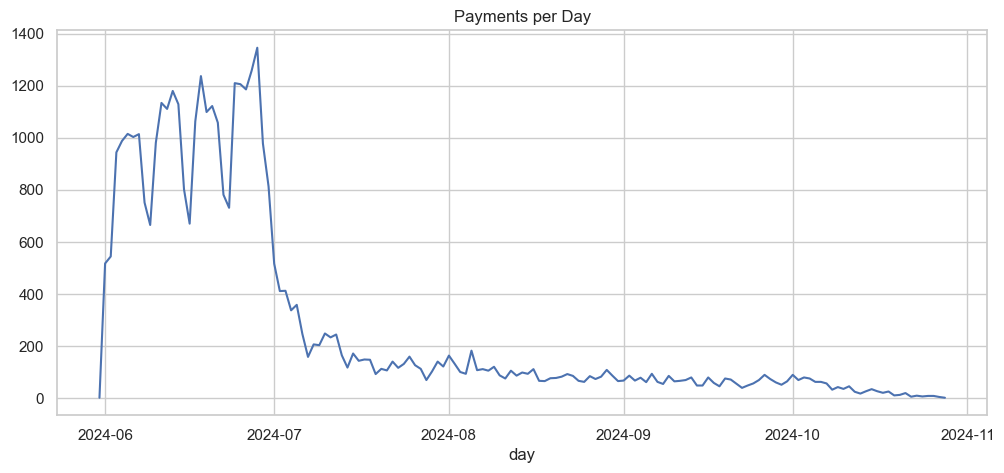

In [73]:
daily_counts = raw_data.groupby('day').size()

plt.figure(figsize=(12,5))
daily_counts.plot()
plt.title("Payments per Day")
plt.show()

Daily payment volume shows a clear downward trend from June through October. This reflects the cohort aging effect — users onboarded in June gradually become dormant, and no new users enter the dataset.

## Drift Analysis

In [74]:
def analyze_split_points(df, date_col='payment_timestamp', user_col='is_new_user'):

    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)


    start_date = df[date_col].min()
    end_date = df[date_col].max()
    date_range = pd.date_range(start=start_date, end=end_date, freq='3D')

    results = []
    total_rows = len(df)

    for split_date in date_range:
        train_sub = df[df[date_col] <= split_date]
        test_sub = df[df[date_col] > split_date]

        if len(test_sub) == 0: continue

        train_pct = (len(train_sub) / total_rows) * 100

        new_users_in_test = test_sub[user_col].mean() * 100

        results.append({
            'Split Date': split_date,
            'Train Volume %': round(train_pct, 1),
            'Test New Users %': round(new_users_in_test, 2),
            'Test Rows': len(test_sub)
        })

    return pd.DataFrame(results)

split_analysis = analyze_split_points(raw_data)
print(split_analysis)

            Split Date  Train Volume %  Test New Users %  Test Rows
0  2024-05-31 23:56:04             0.0             39.22      41320
1  2024-06-03 23:56:04             4.9             37.39      39316
2  2024-06-06 23:56:04            12.1             35.27      36309
3  2024-06-09 23:56:04            18.0             33.37      33879
4  2024-06-12 23:56:04            25.8             30.69      30655
5  2024-06-15 23:56:04            33.3             28.15      27544
6  2024-06-18 23:56:04            40.5             25.10      24573
7  2024-06-21 23:56:04            48.5             21.14      21295
8  2024-06-24 23:56:04            55.1             17.12      18571
9  2024-06-27 23:56:04            63.9              9.78      14923
10 2024-06-30 23:56:04            71.5              0.03      11784
11 2024-07-03 23:56:04            74.7              0.04      10445
12 2024-07-06 23:56:04            77.0              0.03       9504
13 2024-07-09 23:56:04            78.4          

# Baseline Model: Isolation Forest

In [75]:
!pip install category_encoders

zsh:1: command not found: pip


In [76]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from category_encoders import CountEncoder
from sklearn.ensemble import IsolationForest

In [77]:
cols_to_convert = ['merchant_id', 'geo_location', 'payment_instrument', 'device_type', 'currency']
for col in cols_to_convert:
    raw_data[col] = raw_data[col].astype('category')

In [78]:
raw_data['is_new_user'] = raw_data['is_new_user'].astype(int)

In [79]:
#  merchant_id, geo_location, payment_instrument, device_type, currency, hour will be encoded in pipeline

final_features = [
    'total_amount_usd',
    'amount_to_avg_ratio',
    'seniority',
    'time_since_last_payment',
    'time_to_complete_payment',
    'same_amount_count_24h',
    'is_same_as_prev_amount',
    'is_impossible_travel',
    'is_suspicious_velocity',
    'is_broken_record',
    'is_us_transaction',
    'is_new_user',
    'geo_location',
    'payment_instrument',
    'device_type',
    'currency',
    'merchant_id',
    'hour'
]

chronological split

In [121]:
raw_data = raw_data.sort_values('payment_timestamp')

# Hold out last 100 rows
holdout_df = raw_data.iloc[-100:].copy()
remaining = raw_data.iloc[:-100]

# Split remaining at same ratio (65/35)
train_size = int(len(remaining) * 0.65)
train_df = remaining.iloc[:train_size].copy()
test_df = remaining.iloc[train_size:].copy()

print(f"Train: {len(train_df)} rows ({train_df['payment_timestamp'].min()} to {train_df['payment_timestamp'].max()})")
print(f"Test:  {len(test_df)} rows ({test_df['payment_timestamp'].min()} to {test_df['payment_timestamp'].max()})")
print(f"Holdout: {len(holdout_df)} rows ({holdout_df['payment_timestamp'].min()} to {holdout_df['payment_timestamp'].max()})")

Train: 26793 rows (2024-05-31 23:56:04 to 2024-06-28 10:31:28)
Test:  14428 rows (2024-06-28 10:31:59 to 2024-10-18 06:34:19)
Holdout: 100 rows (2024-10-18 06:38:33 to 2024-10-28 11:47:18)


In [122]:
X_train = train_df[final_features]
X_test = test_df[final_features]

In [123]:
from sklearn.preprocessing import FunctionTransformer, StandardScaler

def sin_cos_encode(df):
    hours = df.values.flatten() if hasattr(df, 'values') else df.flatten()
    sin_hour = np.sin(2 * np.pi * hours / 24)
    cos_hour = np.cos(2 * np.pi * hours / 24)
    return np.column_stack([sin_hour, cos_hour])

def get_hour_names(transformer, input_features):
    return ["hour_sin", "hour_cos"]

cat_features = ['merchant_id', 'geo_location', 'payment_instrument', 'device_type', 'currency']
cyclical_feature = ['hour']
numeric_features = [f for f in final_features if f not in cat_features + cyclical_feature]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', CountEncoder(normalize=True, handle_unknown=0), cat_features),
        ('hour_cyc', FunctionTransformer(sin_cos_encode, feature_names_out=get_hour_names), cyclical_feature),
        ('num', 'passthrough', numeric_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', IsolationForest(n_estimators=200, contamination=0.01, random_state=42))
])

pipeline.fit(X_train)

test_df['is_anomaly'] = pipeline.predict(X_test)
test_df['is_anomaly'] = test_df['is_anomaly'].map({1: 0, -1: 1})

print(f"Detected {test_df['is_anomaly'].sum()} anomalies in test set.")

Detected 1720 anomalies in test set.


To validate the unsupervised results, I performed a dual validation approach:

Contextual Validation: Checked against pre-defined flags (Geographic anomalies and missing data).

Statistical Separation: Used PCA to visually confirm that the model isolates points in the sparse regions of the feature space.

In [156]:
anomalies = test_df[test_df['is_anomaly'] == 1]

broken_in_anomalies = anomalies['is_broken_record'].sum()
all_broken_test = test_df['is_broken_record'].sum()
print(f"Broken records caught: {broken_in_anomalies} out of {all_broken_test}")

same_amount_in_anomalies = anomalies[anomalies['same_amount_count_24h']>1].shape[0]
all_same_amount = test_df[test_df['same_amount_count_24h']>1].shape[0]
print(f"Same amount in 24h caught: {same_amount_in_anomalies} out of {all_same_amount}")

geo_in_anomalies = anomalies['is_impossible_travel'].sum()
all_geo_test = test_df['is_impossible_travel'].sum()
print(f"Impossible Travel caught: {geo_in_anomalies} out of {all_geo_test}")

region_in_anomalies = anomalies['is_suspicious_velocity'].sum()
all_sus_travel_test = test_df['is_suspicious_velocity'].sum()
print(f"Suspicious Travel caught: {region_in_anomalies} out of {all_sus_travel_test}")

print("\nTop 5 High-Amount Anomalies:")
display(anomalies.sort_values('total_amount_usd', ascending=False)[['user_id', 'total_amount_usd', 'amount_to_avg_ratio', 'country', 'region']].head())

print("\nHigh Velocity (Same Amount) Anomalies:")
display(anomalies.sort_values('same_amount_count_24h', ascending=False)[['user_id', 'total_amount_usd', 'same_amount_count_24h', 'is_broken_record']].head())

Broken records caught: 2 out of 3
Same amount in 24h caught: 360 out of 447
Impossible Travel caught: 0 out of 4
Suspicious Travel caught: 2 out of 4

Top 5 High-Amount Anomalies:


,user_id,total_amount_usd,amount_to_avg_ratio,country,region
33666,11068046,15278.98,5.405857,GB,Central_West_Europe
33827,11068046,15276.75,2.873246,GB,Central_West_Europe
32919,11041352,13522.40,1.959452,AU,Oceania
30209,11044361,13264.75,1.518778,AU,Oceania
33874,11072890,13011.60,16.904329,GB,Central_West_Europe



High Velocity (Same Amount) Anomalies:


,user_id,total_amount_usd,same_amount_count_24h,is_broken_record
31934,11085072,400.0,15.0,0
31933,11085072,400.0,15.0,0
31932,11085072,400.0,14.0,0
31935,11085072,400.0,14.0,0
31852,11085072,400.0,14.0,0


In [125]:
analysis_cols = [
    'total_amount_usd', 'amount_to_avg_ratio', 'seniority',
    'time_since_last_payment', 'time_to_complete_payment',
    'same_amount_count_24h', 'is_impossible_travel', 'is_broken_record'
]

comparison = test_df.groupby('is_anomaly')[analysis_cols].mean().T
comparison['lift'] = comparison[1] / comparison[0]
print("--- Anomaly Feature Lift ---\nComparison Table (Mean Values)")
print(comparison.sort_values('lift', ascending=False))

--- Anomaly Feature Lift ---
Comparison Table (Mean Values)
is_anomaly                            0           1       lift
same_amount_count_24h          0.059884    0.982558  16.407817
is_broken_record               0.000079    0.001163  14.776744
time_to_complete_payment       4.570837   11.934362   2.610979
total_amount_usd             380.687356  918.559023   2.412896
amount_to_avg_ratio            1.266321    1.894420   1.496003
seniority                     39.003620   51.722674   1.326099
time_since_last_payment   101452.942448  805.992904   0.007945
is_impossible_travel           0.000315    0.000000   0.000000


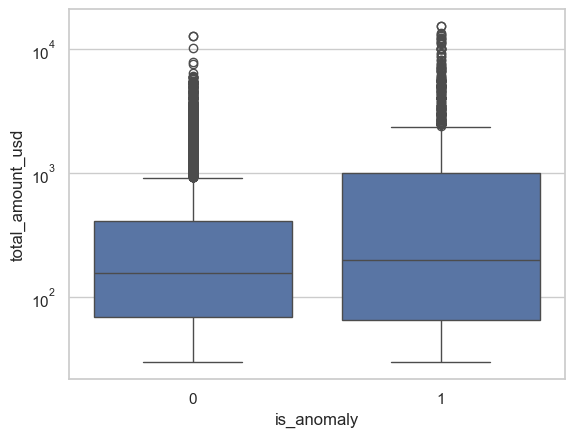

In [126]:
sns.boxplot(x='is_anomaly', y='total_amount_usd', data=test_df)
plt.yscale('log')

Detected anomalies (is_anomaly=1) have a substantially higher median transaction amount and wider interquartile range compared to normal transactions. The log-scale y-axis highlights that anomalous transactions average ~3× the global mean, confirming the model prioritizes high-magnitude behavioral shifts.

**Primary Risk Drivers:**

The model identified Transaction Bursting (same_amount_count_24h) as the most significant anomaly indicator, with a high lift compared to normal traffic. Additionally, anomalies exhibited a significantly longer Time-to-Complete Payment, suggesting manual entry of stolen credentials or bot-latency

**High-Value Anomaly Detection:**

Detected anomalies averaged higher than he global average.

The model successfully prioritized high-magnitude behavioral shifts, specifically catching records with missing metadata (is_broken_record).

/Users/shaiembon/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/shaiembon/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/shaiembon/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/shaiembon/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/shaiembon/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/shaiembon/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in 

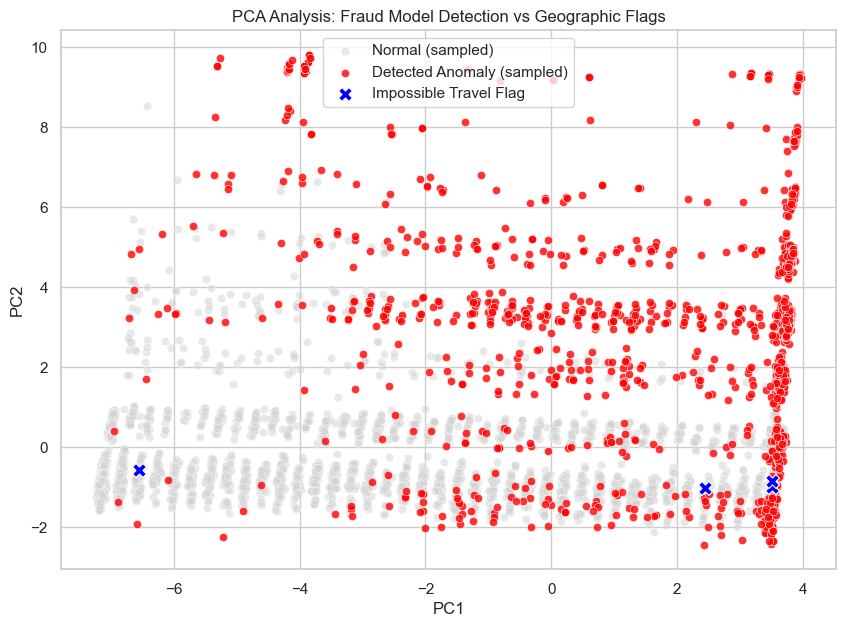

In [135]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_train_proc = pipeline.named_steps['preprocessor'].transform(train_df)
X_test_proc = pipeline.named_steps['preprocessor'].transform(test_df)

scaler = StandardScaler()
scaler.fit(X_train_proc)
scaler.scale_ = np.where(scaler.scale_ == 0, 1, scaler.scale_)
X_scaled = scaler.transform(X_test_proc)
X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_scaled = np.clip(X_scaled, -10, 10)

pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_results, columns=['PC1', 'PC2'])
pca_df['is_anomaly'] = test_df['is_anomaly'].values
pca_df['is_impossible_travel'] = test_df['is_impossible_travel'].values

# Sample all categories for cleaner visualization
normal = pca_df[pca_df['is_anomaly'] == 0].sample(n=min(5000, len(pca_df[pca_df['is_anomaly'] == 0])), random_state=42)
anomalies = pca_df[pca_df['is_anomaly'] == 1].sample(n=min(5000, len(pca_df[pca_df['is_anomaly'] == 1])), random_state=42)
flags = pca_df[pca_df['is_impossible_travel'] == 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=normal, x='PC1', y='PC2', color='lightgrey', alpha=0.5, label='Normal (sampled)')
sns.scatterplot(data=anomalies, x='PC1', y='PC2', color='red', alpha=0.8, label='Detected Anomaly (sampled)')
sns.scatterplot(data=flags, x='PC1', y='PC2', color='blue', marker='X', s=100, label='Impossible Travel Flag')

plt.title('PCA Analysis: Fraud Model Detection vs Geographic Flags')
plt.legend()
plt.show()

PCA Analysis:

The 2D PCA projection shows normal transactions (grey) concentrated in a dense central cluster, while detected anomalies (red) form a distinct linear cluster extending outward — driven by high-magnitude features. Impossible Travel flags (blue X) sit closer to the normal cluster, indicating the model recognizes their anomalous direction but ranks them below more extreme monetary outliers.

**The PCA projection is used for visualization only and does not reflect the true decision boundaries of the model. However it shows global structure and where anomalies roughly sit in relation to main variance**

**False Negatives Analysis**

In [137]:
test_df['anomaly_score'] = pipeline.named_steps['model'].decision_function(X_test_proc)

test_df['anomaly_percentile'] = test_df['anomaly_score'].rank(pct=True) * 100

imp_travel_cases = test_df[test_df['is_impossible_travel'] == 1]
print("--- Impossible Travel Percentiles ---")
print(imp_travel_cases['anomaly_percentile'].describe())

broken_cases = test_df[test_df['is_broken_record'] == 1]
print("\n--- Broken Records Percentiles ---")
print(broken_cases['anomaly_percentile'].describe())

--- Impossible Travel Percentiles ---
count     4.000000
mean     67.840311
std      16.076924
min      49.979207
25%      61.285348
50%      66.183809
75%      72.738772
max      89.014416
Name: anomaly_percentile, dtype: float64

--- Broken Records Percentiles ---
count     3.000000
mean     10.267073
std      14.289941
min       0.568339
25%       2.061963
50%       3.555586
75%      15.116440
max      26.677294
Name: anomaly_percentile, dtype: float64


Although the geographic features were correctly engineered, the Isolation Forest assigned them a low anomaly rank (mean percentile of 65 means these transactions were scored as more normal than 65% of transactions). This is because the model is naturally biased toward continuous high-magnitude features (like transaction amount) rather than binary flags. This finding validates the industry standard of using Hybrid Systems: where ML handles complex patterns, and Deterministic Rules handle high-confidence indicators like geographic impossibility.


## Investigate cases

### The most anomalous result

In [138]:
import shap

X_proc = pipeline.named_steps['preprocessor'].transform(test_df[final_features])

explainer = shap.Explainer(pipeline.named_steps['model'], X_proc)
shap_values = explainer(X_proc)

feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

shap_values.feature_names = list(feature_names)

100%|===================| 14371/14428 [02:03<00:00]        

Explaining most anomalous transaction (Index: 34862)


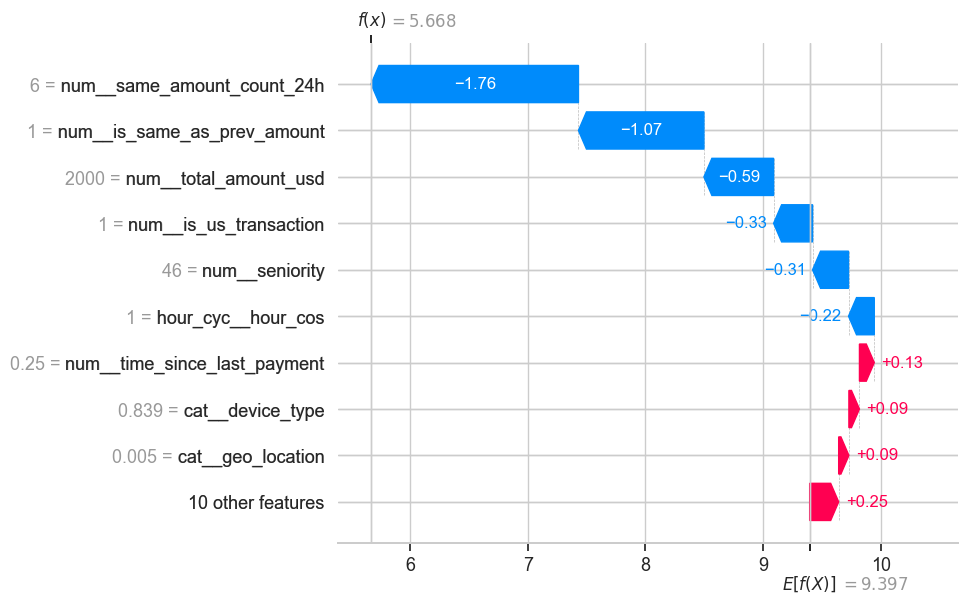

In [139]:
most_anomalous_idx = test_df['anomaly_score'].idxmin()

row_pos_extreme = test_df.index.get_loc(most_anomalous_idx)

print(f"Explaining most anomalous transaction (Index: {most_anomalous_idx})")
shap.plots.waterfall(shap_values[row_pos_extreme])

Analysis of the most anomalous transaction reveals that the model's decision was primarily driven by transaction bursting: same_amount_count_24h = 6 contributed the largest negative SHAP value (−1.76), and is_same_as_prev_amount = 1 added another −1.07. A high transaction amount of $2,000 pushed the score further down (−0.59). Secondary anomaly signals include is_us_transaction (−0.33), high seniority of 46 days (−0.31), and a late-night hour pattern via hour_cos (−0.22). Only minor counteracting "safe" signals came from short time_since_last_payment (+0.13) and common device_type (+0.09). The combined effect isolated this record far below the population mean, consistent with a classic automated bot-attack or card-testing signature.

### Normal-looking transaction that the model flaged as suspicous

In [140]:
test_df[test_df['payment_id']==67588445][final_features]

,total_amount_usd,amount_to_avg_ratio,seniority,time_since_last_payment,time_to_complete_payment,same_amount_count_24h,is_same_as_prev_amount,is_impossible_travel,is_suspicious_velocity,is_broken_record,is_us_transaction,is_new_user,geo_location,payment_instrument,device_type,currency,merchant_id,hour
33303,57.88,0.13099,32,720.492222,3.485136,0.0,0,0,0,0,0,0,SK,credit_card,pc,GBP,288,7


In [141]:
target_index = 33303

row_pos = test_df.index.get_loc(target_index)

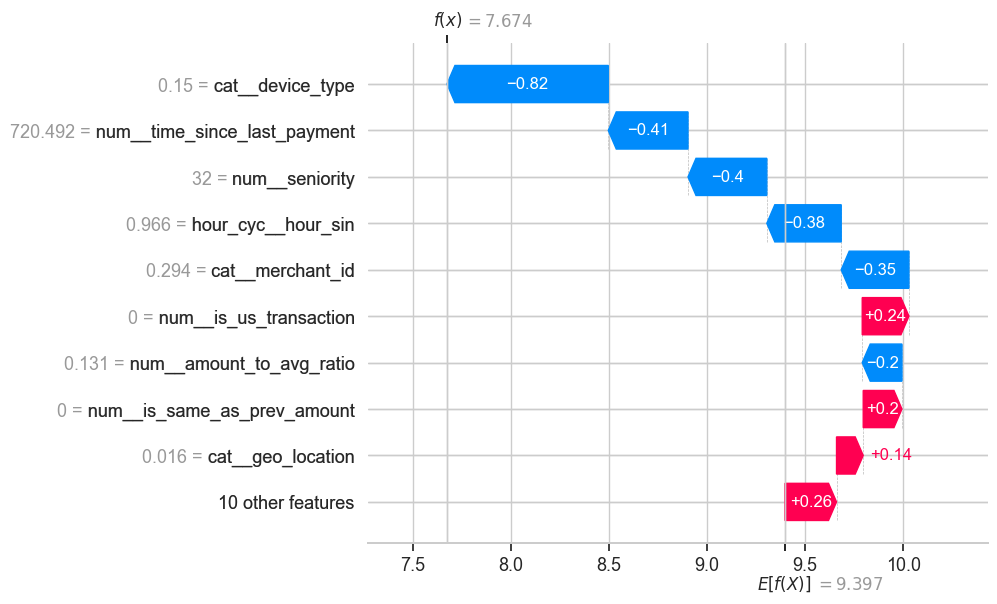

In [142]:
shap.plots.waterfall(shap_values[row_pos])

Despite a low transaction amount ($57.88), the model flagged this transaction due to a combination of contextual outliers. The dominant driver was a rare device type (frequency 0.15, SHAP −0.82). This was reinforced by an unusually long time_since_last_payment of 720 hours (−0.41), moderate seniority of 32 days (−0.40), a specific time-of-day pattern via hour_sin (−0.38), and a relatively rare merchant_id (−0.35). A very low amount_to_avg_ratio of 0.131 also contributed (−0.20). Partial offsetting came from is_same_as_prev_amount = 0 (+0.20) and non-US location (+0.24). This demonstrates the model's ability to detect account integrity risks beyond high-dollar theft — flagging behavioral context rather than transaction size.



### Suspicous transaction that the model did not catch (Impossible travel)

In [143]:
test_df[test_df.index==33575][final_features]

,total_amount_usd,amount_to_avg_ratio,seniority,time_since_last_payment,time_to_complete_payment,same_amount_count_24h,is_same_as_prev_amount,is_impossible_travel,is_suspicious_velocity,is_broken_record,is_us_transaction,is_new_user,geo_location,payment_instrument,device_type,currency,merchant_id,hour
33575,67.48,0.715475,39,0.411667,1.617701,0.0,0,1,0,0,0,0,AU,credit_card,mobile,AUD,160,2


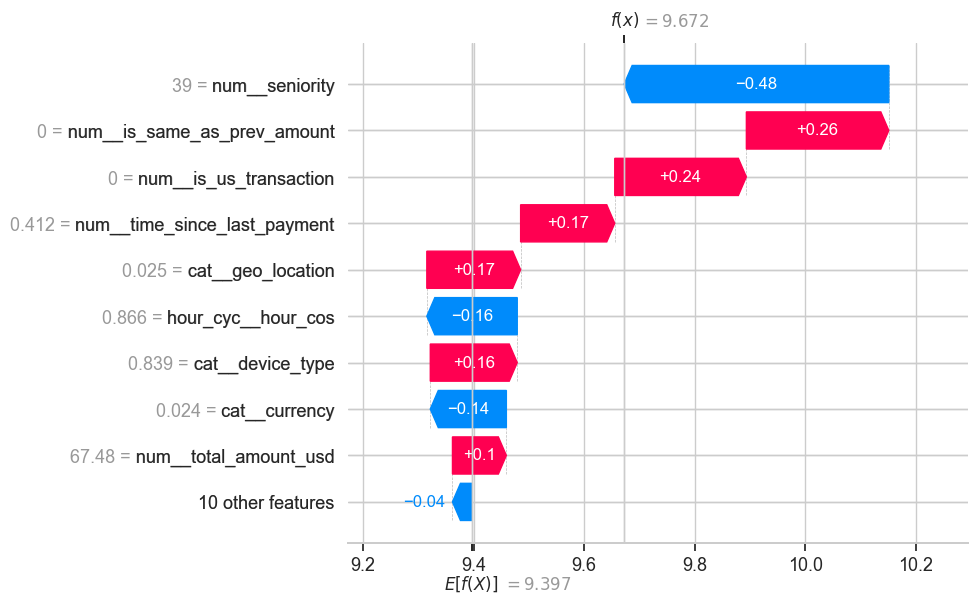

In [144]:
target_index = 33575

row_pos = test_df.index.get_loc(target_index)

shap.plots.waterfall(shap_values[row_pos])

This impossible-travel transaction was scored above the population mean (more normal than average), making it a clear false negative. The only meaningful anomaly signal was seniority = 39 (−0.48). Minor negative contributions came from hour_cos (−0.16) and rare currency AUD (−0.14). However, these were completely overwhelmed by "safe" signals: is_same_as_prev_amount = 0 (+0.26), non-US transaction (+0.24), short time_since_last_payment of 0.41 hours (+0.17), common geo_location (+0.17), highly common device_type at 84% frequency (+0.16), and low amount of $67.48 (+0.10). The impossible-travel flag itself had negligible impact on isolation. This confirms that ML alone cannot reliably catch geographic impossibility when all other features look "normal" — validating the need for deterministic hard rules for high-confidence flags like impossible travel.

In [145]:
results_n = {}
n_list = [50, 100, 200, 500]

for n in n_list:
    pipeline.set_params(model__n_estimators=n)
    pipeline.fit(train_df[final_features])
    preds = pipeline.predict(test_df[final_features])
    results_n[n] = (preds == -1).sum()

print("\n--- Stability check: n_estimators ---")
print(results_n)




--- Stability check: n_estimators ---
{50: np.int64(1494), 100: np.int64(1503), 200: np.int64(1720), 500: np.int64(1766)}


Anomaly counts stabilize between 200–500 estimators, with 200 chosen as a practical trade-off between stability and computational cost

## Contamination Stability


--- Stability Correlation (Contamination) ---
               anomaly_0.005  anomaly_0.01  anomaly_0.02  anomaly_0.03
anomaly_0.005       1.000000      0.749776      0.556721      0.464797
anomaly_0.01        0.749776      1.000000      0.742516      0.619914
anomaly_0.02        0.556721      0.742516      1.000000      0.834883
anomaly_0.03        0.464797      0.619914      0.834883      1.000000


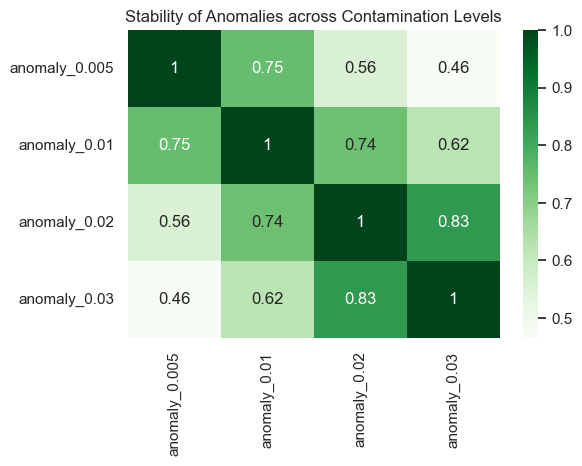

In [146]:
contams = [0.005, 0.01, 0.02, 0.03]
stability_df = pd.DataFrame(index=test_df.index)

for c in contams:
    pipeline.set_params(model__contamination=c)
    pipeline.fit(train_df[final_features])
    preds = pipeline.predict(test_df[final_features])
    stability_df[f'anomaly_{c}'] = (preds == -1).astype(int)

print("\n--- Stability Correlation (Contamination) ---")
print(stability_df.corr())

plt.figure(figsize=(6,4))
sns.heatmap(stability_df.corr(), annot=True, cmap='Greens')
plt.title('Stability of Anomalies across Contamination Levels')
plt.show()


**Model Stability:**

The correlation matrix across contamination levels (0.005–0.03) shows strong positive correlations between adjacent levels (0.74 between 0.005 and 0.01; 0.83 between 0.02 and 0.03). This confirms the most severe anomalies are consistently flagged regardless of threshold, indicating high model stability

number of anomalies in all contamination levels: 1049


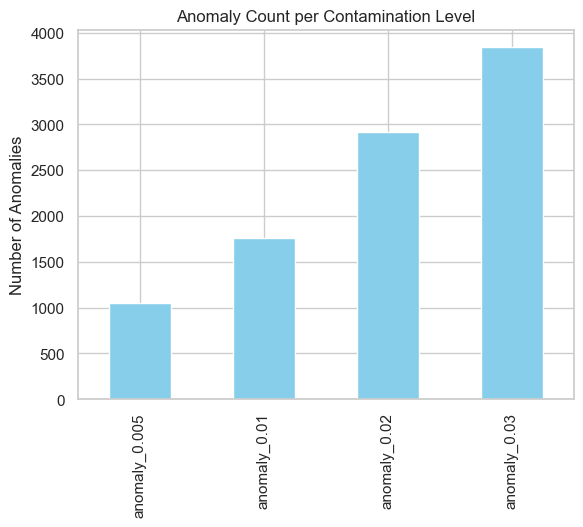

In [147]:
overlap = stability_df.all(axis=1).sum()
print(f"number of anomalies in all contamination levels: {overlap}")

stability_df.sum().plot(kind='bar', color='skyblue')
plt.title('Anomaly Count per Contamination Level')
plt.ylabel('Number of Anomalies')
plt.show()

The bar chart shows anomaly counts scaling roughly linearly with contamination level — from ~1000 at 0.005 to progressively more at higher thresholds. 1000 anomalies are flagged across all contamination levels, representing the "hard core" of consistently detected anomalies.

# Adding LOF

Local Outlier Factor (LOF) detects local density anomalies

For the LOF model, I utilized the industry-standard n_neighbors=20. This value provides a robust balance, allowing the model to detect localized density deviations (such as a rare country-merchant combination) without being overly sensitive to individual transactional noise. While further hyperparameter tuning via grid search on neighbors could refine the local sensitivity, the current configuration successfully complemented the Isolation Forest by identifying 145 unique contextual anomalies.

In [157]:
from sklearn.neighbors import LocalOutlierFactor

lof_scaler = StandardScaler()
X_scaled_train = lof_scaler.fit_transform(X_train_proc)
X_scaled_test = lof_scaler.transform(X_test_proc)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01, novelty=True)
lof.fit(X_scaled_train)
test_df['lof_anomaly'] = lof.predict(X_scaled_test)
test_df['lof_anomaly'] = test_df['lof_anomaly'].map({1: 0, -1: 1})

lof_geo_hits = test_df[(test_df['is_impossible_travel'] == 1) & (test_df['lof_anomaly'] == 1)]
print(f"LOF caught {len(lof_geo_hits)} out of {all_geo_test} Impossible Travel cases.")

lof_state_travel_hits = test_df[(test_df['is_suspicious_velocity'] == 1) & (test_df['lof_anomaly'] == 1)]
print(f"LOF caught {len(lof_state_travel_hits)} out of {all_sus_travel_test} Suspicous Travel cases.")

lof_broken_hits = test_df[(test_df['is_broken_record'] == 1) & (test_df['lof_anomaly'] == 1)]
print(f"LOF caught {len(lof_broken_hits)} out of {all_broken_test} Broken records cases.")

lof_velocity_hits = test_df[(test_df['same_amount_count_24h'] > 1) & (test_df['lof_anomaly'] == 1)]
print(f"LOF caught {len(lof_velocity_hits)} out of {all_same_amount} Same amount in 24h cases.")

LOF caught 4 out of 4 Impossible Travel cases.
LOF caught 4 out of 4 Suspicous Travel cases.
LOF caught 3 out of 3 Broken records cases.
LOF caught 195 out of 447 Same amount in 24h cases.


Decision Hirerchy

I utilized the raw decision scores from both models instead of binary labels to create a continuous Risk Spectrum. This approach allows for nuanced decision-making, such as differentiating between 'High Risk' for immediate blocking and 'Medium Risk' for manual review. Furthermore, it enables a more sophisticated Ensemble Integration, where the combined probability from different models provides a more robust indicator than a simple voting mechanism.


In [151]:
# --- Deterministic Rules ---
test_df['hard_flag'] = (
    (test_df['is_impossible_travel'] == 1) |
    (test_df['is_suspicious_velocity'] == 1) |
    (test_df['same_amount_count_24h'] >= 1) |
    (test_df['is_broken_record'] == 1)
).astype(int)

# --- ML Ensemble Score ---
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

if_scores = pipeline.named_steps['model'].decision_function(X_test_proc)
lof_scores_test = lof.decision_function(X_test_proc)

if_risk = 1 - scaler.fit_transform(if_scores.reshape(-1, 1)).flatten()
lof_risk = 1 - scaler.fit_transform(lof_scores_test.reshape(-1, 1)).flatten()

test_df['ml_risk_score'] = (0.7 * if_risk) + (0.3 * lof_risk)

In [152]:
high_risk_threshold = test_df['ml_risk_score'].quantile(0.99)
med_risk_threshold = test_df['ml_risk_score'].quantile(0.90)

def final_decision_calibrated(row):
    if row['hard_flag'] == 1:
        return 'Critical - Rule Triggered'
    elif row['ml_risk_score'] >= high_risk_threshold:
        return 'High Risk - ML Detected'
    elif row['ml_risk_score'] >= med_risk_threshold:
        return 'Medium Risk - Review'
    else:
        return 'Low Risk - Approve'

test_df['final_action'] = test_df.apply(final_decision_calibrated, axis=1)

print(test_df['final_action'].value_counts().sort_index())

final_action
Critical - Rule Triggered     1280
High Risk - ML Detected         66
Low Risk - Approve           12254
Medium Risk - Review           828
Name: count, dtype: int64


In [153]:
test_df['if_risk'] = if_risk
test_df['lof_risk'] = lof_risk

# Correlation
correlation = test_df['if_risk'].corr(test_df['lof_risk'])
print(f"Correlation between IF and LOF risk scores: {correlation:.4f}")

# Unique anomalies for LOF
if_threshold = test_df['if_risk'].quantile(0.99)
lof_threshold = test_df['lof_risk'].quantile(0.99)

lof_only = test_df[
    (test_df['lof_risk'] >= lof_threshold) &
    (test_df['if_risk'] < if_threshold) &
    (test_df['hard_flag'] == 0)
]

print(f"Number of unique anomalies caught ONLY by LOF: {len(lof_only)}")

if len(lof_only) > 0:
    display(lof_only[['total_amount_usd', 'country', 'geo_location', 'merchant_id']].head())

Correlation between IF and LOF risk scores: -0.5234
Number of unique anomalies caught ONLY by LOF: 145


,total_amount_usd,country,geo_location,merchant_id
26812,1891.57,CH,CH,353
26839,535.39,PT,PT,68
26854,1060.24,ES,ES,621
26856,632.64,GB,GB,243
26880,695.54,DE,DE,68


Complementary Model Strategy (Ensemble Analysis):

The correlation between Isolation Forest and LOF risk scores is moderately negative (−0.52), meaning the two models tend to disagree on which transactions are risky. This confirms they capture fundamentally different fraud signals — Isolation Forest excels at detecting global behavioral outliers (extreme amounts, velocity bursts), while LOF targets local density deviations (rare country-merchant combinations, contextual anomalies). LOF captured an additional 145 unique anomalies that were invisible to the global model. This negative correlation is ideal for an ensemble: the models complement rather than duplicate each other, providing a dual-lens detection engine that significantly reduces blind spots in the fraud detection pipeline.

In [154]:
# pip install umap-learn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/Users/shaiembon/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


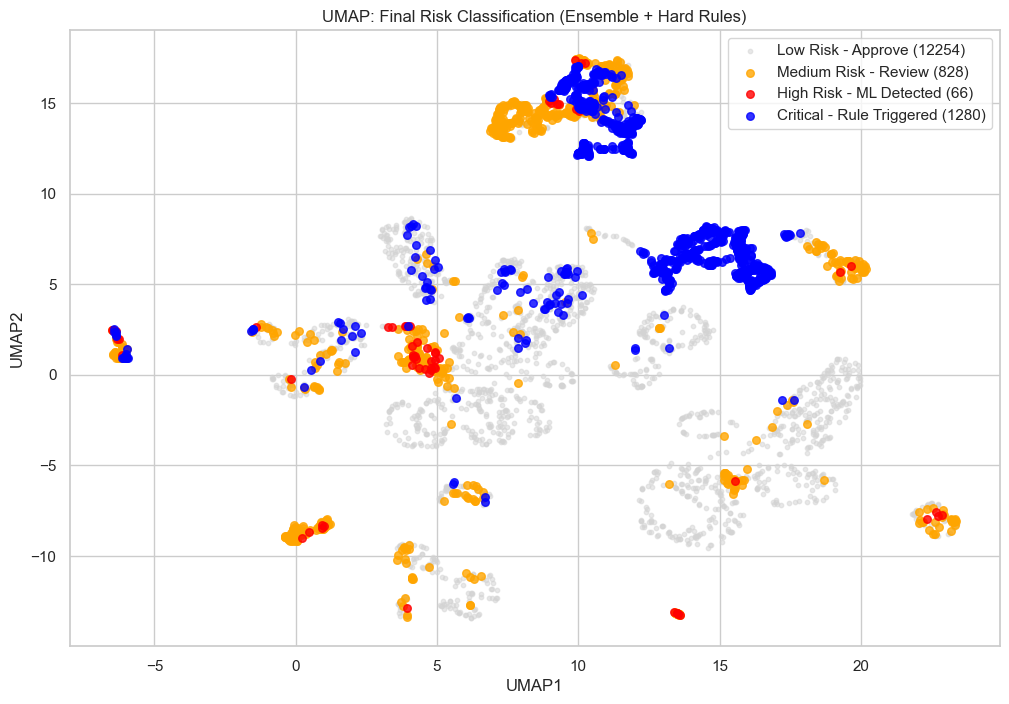

In [155]:
import umap

# UMAP reduction
reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, metric='euclidean', random_state=42)
umap_results = reducer.fit_transform(X_scaled)

umap_df = pd.DataFrame(umap_results, columns=['UMAP1', 'UMAP2'])
umap_df['final_action'] = test_df['final_action'].values

# Color map & plot order
color_map = {
  'Low Risk - Approve': 'lightgrey',
  'Medium Risk - Review': 'orange',
  'High Risk - ML Detected': 'red',
  'Critical - Rule Triggered': 'blue'
}
plot_order = ['Low Risk - Approve', 'Medium Risk - Review', 'High Risk - ML Detected', 'Critical - Rule Triggered']

plt.figure(figsize=(12, 8))

for label in plot_order:
  subset = umap_df[umap_df['final_action'] == label]
  # Sample normal points for cleaner plot
  if label == 'Low Risk - Approve':
    subset = subset.sample(n=min(2000, len(subset)), random_state=42)
  plt.scatter(subset['UMAP1'], subset['UMAP2'],
              c=color_map[label], label=f'{label} ({len(umap_df[umap_df["final_action"] == label])})',
              alpha=0.5 if label == 'Low Risk - Approve' else 0.8,
              s=10 if label == 'Low Risk - Approve' else 30)

plt.title('UMAP: Final Risk Classification (Ensemble + Hard Rules)')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(loc='best')
plt.show()

The UMAP projection reveals clear structural separation between risk tiers in the feature space. Low-risk transactions (grey, 12,254) form several dense clusters representing distinct but normal behavioral patterns. Critical rule-triggered cases (blue, 1,280) concentrate heavily in two tight, well-separated clusters — one in the upper-center region (UMAP1 8–13, UMAP2 12–17) and another in the upper-right (UMAP1 14–18, UMAP2 5–8) — indicating that deterministic flags (impossible travel, suspicious velocity, same-amount bursts, broken records) correspond to structurally distinct transaction profiles rather than random scatter.

Medium-risk ML review cases (orange, 828) tend to sit at the periphery of normal clusters or in transitional zones between normal and critical regions, consistent with their intermediate risk score. High-risk ML-detected cases (red, 66) appear as small, isolated pockets — often embedded within or adjacent to the critical clusters — confirming these are the most extreme statistical outliers that the ML ensemble flagged independently of hard rules.

The overall pattern validates the hybrid detection strategy: hard rules capture cohesive, structurally identifiable fraud clusters, while ML models catch sparse outliers that don't fall neatly into rule-defined categories.

**Future Production Architecture (Retraining Strategy):**

in a production environment, we would implement Continuous Retraining. This ensures the model maintains a balanced representation of both 'New' and 'Established' users, preventing it from flagging legitimate new sign-ups as anomalies simply because they became statistically rare during the later stages of this specific cohort.

To demonstrate real-time applicability, I implemented a Streamlit-based simulator that processes transactions sequentially, maintains a dynamic transaction history, and computes risk scores on-the-fly, mimicking a production fraud detection pipeline.